<h1 align="center">
  <span style="color: purple;"> Thresholding </span>
</h1>

### Table of contents

[1. Overview](#1) <br>
[2. Setup](#2) <br>
[3. Loading data](#3) <br>
[4. Feature Engineer](#4) <br>
[5. Data Quality](#5) <br>
[5. Feature distributions](#6) <br>
[6. Feature scale comparisson](#7) <br>
[7. Correlation analysis](#8) <br>
[9. Temporal structure](#9) <br>
[10. Validation Anomaly Distributions](#10) <br>
    &emsp;&emsp; [10.1. Where are the anomalies?](#10.1) <br>
    &emsp;&emsp; [10.2. Compare normal vs anomalous distributions](#10.2) <br>
    &emsp;&emsp; [10.3. Anomalies over the feature space](#10.3) <br>
[11. Summary](#2) <br>

<a id="1"></a>
<h2 align="center">
  <span style="color: #440E03;">1. Overview </span>
</h2>


An anomaly detector typically produces a continuous **anomaly score** rather than a binary prediction. The score indicates how unusual an observation is, but a decision still has to be made about when an observation should be considered anomalous.

Given an anomaly score $s(x)$, thresholding converts it into a binary decision:

$$
\hat{y} =
\begin{cases}
1 & \text{if } s(x) > \tau \\
0 & \text{otherwise}
\end{cases}
$$

where $\tau$ is the threshold.

The purpose of this notebook is to study **how thresholds can be selected in anomaly-detection systems**, and, more importantly, **when each strategy is appropriate**.

The emphasis is therefore not on collecting thresholding implementations. Instead, we will focus on the reasoning behind threshold selection:

- what information is available when selecting the threshold;
- whether anomaly labels are available;
- which data should be used for threshold calibration;
- what assumptions each strategy makes;
- how the desired operating point affects the choice of threshold;
- how threshold selection interacts with model evaluation and model selection;
- and how these choices change when the data are temporal or windowed.

The main question throughout the notebook is:

> **Given the anomaly scores and the information available about the data, how should we choose a threshold?**

---


<b> <font color='blue'> <h3> Thresholding as a decision problem </h3> </font></b>

An anomaly detector and its threshold solve two different problems.

The **anomaly detector** produces a score:

$$
x \rightarrow s(x)
$$

The **thresholding strategy** converts that score into a decision:

$$
s(x) \rightarrow \hat{y}
$$

This distinction is important because two detectors can produce scores on completely different scales. A threshold such as $\tau = 0.5$ has no universal meaning across models.

Threshold selection is therefore part of the overall anomaly-detection pipeline rather than a fixed property of the detector itself.

A useful abstraction is:

$$
\text{data}
\rightarrow
\text{preprocessing}
\rightarrow
\text{anomaly detector}
\rightarrow
\text{scores}
\rightarrow
\text{threshold selection}
\rightarrow
\text{binary predictions}
$$

The appropriate thresholding strategy depends on what is known about the data at the point where the threshold is selected.

---

<b> <font color='blue'> <h3> What we will study </h3> </font></b>

We will organize threshold selection according to the information available during calibration.

**Unsupervised threshold selection**

No anomaly labels are available.

Examples include:

- quantile-based thresholds;
- statistical thresholds;
- robust thresholds.

These methods generally rely on assumptions about the score distribution or about the proportion of observations that should be considered anomalous.

**Supervised threshold selection**

Labeled data are available.

The threshold can then be selected using an explicit objective, such as:

- maximizing F1;
- achieving a minimum recall;
- satisfying a maximum false-positive rate;
- minimizing an application-specific cost.

In this setting, threshold selection becomes a validation/calibration problem.

**Operational threshold selection**

Sometimes the objective is not primarily a statistical metric.

For example, an anomaly-detection system may have a constraint such as:

> The system can investigate at most 20 alerts per day.

or:

> Missing an anomaly is substantially more costly than investigating a false alarm.

In these cases, the threshold should be derived from the operational constraint rather than simply choosing the threshold that maximizes a generic metric.

---

<b> <font color='blue'> <h3> The data used for threshold selection </h3> </font></b>

A central question is:

> **Which data should be used to determine the threshold?**

This depends on the thresholding strategy and on the experimental setup.

For a typical anomaly-detection experiment, we can distinguish three roles:

| Dataset | Main purpose |
|---|---|
| Training data | Fit the anomaly detector and any preprocessing that requires fitting |
| Validation / calibration data | Select the threshold and make model-selection decisions |
| Test data | Final, unbiased evaluation after the decisions are frozen |

For example:

```
Training data
    ↓
fit preprocessing
    ↓
fit anomaly detector
    ↓
Validation data
    ↓
generate anomaly scores
    ↓
select threshold
    ↓
evaluate candidate
    ↓
freeze model + threshold
    ↓
Test data
    ↓
final evaluation
``` 

<b> <font color='blue'> <h3> Why is there no universally best thresholding method </h3> </font></b>

There is no thresholding strategy that is optimal for every anomaly-detection problem.

The appropriate method depends on several factors:

- Are anomaly labels available?
- How reliable are those labels?
- Is the calibration data mostly normal?
- How common are anomalies expected to be?
- Is there an operational limit on the number of alerts?
- Is missing an anomaly more costly than generating a false alarm?
- Is the data distribution stable over time?
- Does the detector operate on individual observations or windows?

For example, a 99th-percentile threshold can be reasonable when there are no labels and the calibration data are expected to be mostly normal. The same strategy may be inappropriate when labeled anomalies are available and the application has a specific recall requirement.

The goal of this notebook is therefore to connect data characteristics and available information to an appropriate thresholding strategy.

<b> <font color='blue'> <h3> Thresholding strategies covered in this notebook </h3> </font></b>

We will examine several families of approaches.

**Without anomaly labels**
- Quantile-based thresholds
- Parametric statistical thresholds
- Robust statistical thresholds

**With anomaly labels**
- Metric-based threshold selection
- Constraint-based threshold selection
- Cost-sensitive threshold selection

**Additional considerations**
- Threshold stability
- Class imbalance
- Temporal data
- Windowed anomaly detection
- Threshold recalibration
- The interaction between threshold selection and model selection

For each strategy, the focus will be on four questions:

- How does the method work?
- What assumptions does it make?
- When is it appropriate?
- What are its limitations?

The implementations will be kept simple and reproducible so that the notebook can serve as a reference for future anomaly-detection projects.


<b> <font color='blue'> <h3> A useful mental model </h3> </font></b>

A useful way to think about threshold selection is:

The anomaly detector determines how observations are ordered by abnormality; the threshold determines where we place the decision boundary.

The detector might produce scores such as:

$$ [0.02,\;0.05,\;0.07,\;0.12,\;0.31,\;0.87] $$

The threshold determines which part of this ordered set is treated as anomalous.

Therefore, threshold selection is fundamentally about choosing an operating point based on the information and constraints available.

This distinction will be maintained throughout the notebook:

- Detection → How are observations scored?
- Thresholding → Where is the decision boundary placed?
- Evaluation → How well does that decision perform?
- Model selection → Which detector and configuration should ultimately be used?

Keeping these decisions separate helps avoid data leakage and makes the resulting anomaly-detection pipeline easier to reason about and deploy.

<a id="2"></a>
<h2 align="center">
  <span style="color: #440E03;">2. Setup </span>
</h2>


In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

<a id="3"></a>
<h2 align="center">
  <span style="color: #440E03;">3. Threshoding as a decision problem</span>
</h2>

An anomaly detector typically produces a continuous **anomaly score** rather than a binary prediction.

For an observation $x$, the detector produces:

$$
s(x) \in \mathbb{R}
$$

where larger values indicate greater abnormality.

A threshold $\tau$ converts this continuous score into a binary decision:

$$
\hat{y} =
\begin{cases}
1 & \text{if } s(x) > \tau \\
0 & \text{otherwise}
\end{cases}
$$

where:

- $s(x)$ is the anomaly score;
- $\tau$ is the selected threshold;
- $\hat{y}=1$ means the observation is classified as anomalous;
- $\hat{y}=0$ means the observation is classified as normal.

**A simple example**

Suppose an anomaly detector produces the following scores:

$$
[0.12,\;0.18,\;0.23,\;0.41,\;0.72,\;1.10]
$$

If we choose:

$$
\tau = 0.50
$$

then the resulting predictions are:

$$
[0,\;0,\;0,\;0,\;1,\;1]
$$

The important point is that **the detector did not produce these binary decisions**. It only produced the scores.

The thresholding step introduced the decision boundary.

**Why this distinction matters**

The numerical value of a threshold has no universal meaning.

For example, a threshold of $0.5$ could be reasonable for one detector and completely inappropriate for another. Different anomaly detectors can produce scores with very different scales and distributions.

Therefore, the threshold should generally be treated as a **separate calibration or decision-making problem**.

Conceptually:

$$
\text{observation}
\rightarrow
\boxed{\text{anomaly detector}}
\rightarrow
\text{score}
\rightarrow
\boxed{\text{threshold}}
\rightarrow
\text{decision}
$$

The detector answers:

> **How anomalous does this observation appear?**

The threshold answers:

> **How anomalous does an observation need to be before we act on it?**

**Threshold selection changes the operating point**

The same anomaly scores can produce different decisions depending on the threshold.

For example:

$$
\tau = 0.20
$$

produces:

$$
[0,0,1,1,1,1]
$$

while:

$$
\tau = 0.80
$$

produces:

$$
[0,0,0,0,0,1]
$$

Thus, changing the threshold changes the number of observations classified as anomalous.

This creates a fundamental trade-off:

- **Lower threshold** → more observations are flagged;
- **Higher threshold** → fewer observations are flagged.

Which operating point is appropriate depends on the characteristics and objectives of the anomaly-detection problem.

This is why threshold selection cannot be separated from the context in which the detector will be used.

In [8]:
scores = np.array([0.12, 0.18, 0.23, 0.41, 0.72, 1.10])


def make_preds(scores, threshold):
    predictions = (scores > threshold).astype(int)
    return predictions

thresholds = [0.5, 0.9]

for t in thresholds:
    print(f"Threshold: {t}, preds: {make_preds(scores, t)}")
    


Threshold: 0.5, preds: [0 0 0 0 1 1]
Threshold: 0.9, preds: [0 0 0 0 0 1]


<a id="4"></a>
<h2 align="center">
  <span style="color: #440E03;">4. What we will study</span>
</h2>


The appropriate thresholding strategy depends primarily on the information available when the threshold is selected.

The most important distinction is whether **anomaly labels are available**.

We can broadly divide threshold selection into three situations:

1. **No anomaly labels are available**
2. **Anomaly labels are available**
3. **Labels or statistical information are available, but the final decision is driven by operational constraints**

These situations lead to different thresholding strategies and different assumptions.

---

**No anomaly labels**

Suppose we have anomaly scores but no information about which observations are actually anomalous.

For example:

$$
s = [0.12,\;0.15,\;0.18,\;0.21,\;0.24,\;0.91]
$$

Without labels, we cannot directly ask:

> Which threshold gives the best recall?

or:

> Which threshold gives the best F1?

because we do not know which observations are truly anomalous.

Instead, we need to use information about the **score distribution** or assumptions about the data.

Examples include:

- selecting a high quantile of the scores;
- estimating the distribution of scores and selecting a tail probability;
- using a robust measure of dispersion.

These approaches are therefore **unsupervised thresholding strategies**.

Their validity depends on assumptions such as:

- the calibration data are representative of the population;
- the calibration data contain relatively few anomalies;
- or the chosen alert rate is appropriate for the application.

We will examine these assumptions explicitly rather than treating methods such as quantile thresholding as universally applicable.

---

**Anomaly labels are available**

If we have labeled data:

$$
(X_{\text{val}}, y_{\text{val}})
$$

we can generate anomaly scores and compare the resulting predictions against the known labels.

This allows the threshold itself to be selected using a supervised criterion.

For example, we can evaluate:

$$
\text{precision}(\tau),
\quad
\text{recall}(\tau),
\quad
F_1(\tau)
$$

for different thresholds.

We can then define an explicit objective such as:

$$
\tau^* = \arg\max_{\tau} F_1(\tau)
$$

However, maximizing F1 is only one possible objective.

Depending on the application, we might instead require:

$$
\text{recall}(\tau) \geq 0.90
$$

and select the threshold that satisfies this constraint while controlling false positives.

The important concept is:

> **Once labels are available, threshold selection can be based on the actual consequences of different decisions rather than only on assumptions about the score distribution.**

We will therefore distinguish between different supervised objectives instead of presenting a single "optimal threshold" method.

---

**Operational constraints**

In real anomaly-detection systems, the desired operating point may come from an operational requirement rather than directly from a standard classification metric.

For example, suppose an operations team can investigate at most 10 alerts per hour.

A threshold that produces 100 alerts per hour may have excellent recall but still be unusable operationally.

Conversely, a very high threshold may produce very few alerts but miss important anomalies.

In such cases, threshold selection can incorporate constraints such as:

- maximum acceptable alert rate;
- minimum required recall;
- maximum false-positive rate;
- relative costs of false positives and false negatives;
- investigation capacity.

This leads to a more general view of threshold selection:

$$
\boxed{
\text{Choose the threshold that satisfies the relevant objective and constraints}
}
$$

rather than:

$$
\text{Always maximize one particular metric}
$$

---

**The main decision framework**

The strategies studied in this notebook can therefore be organized as follows:

```
                 Are anomaly labels available?
                         │
              ┌──────────┴──────────┐
              │                     │
             No                    Yes
              │                     │
              ▼                     ▼
     Use score/distribution     Use labeled data
          information                 │
              │                       │
       ┌──────┴──────┐         ┌──────┴─────────┐
       │             │         │                │
   Quantile       Statistical  Metric-based   Constraint/
   methods        / robust     selection      cost-based
                  methods
``` 



For each strategy, we will ask:

- What information does it require?
- What assumptions does it make?
- What data should be used?
- What objective does it optimize or satisfy?
- When is it appropriate?
- What can go wrong?

The goal is not to identify one universally superior thresholding method.

Instead, the goal is to understand how to choose a thresholding strategy based on the information and constraints of the anomaly-detection problem.

<a id="5"></a>
<h2 align="center">
  <span style="color: #440E03;">5. The data used for threshold selection</span>
</h2>

Choosing a threshold requires data on which to evaluate candidate thresholds.

A critical question is therefore:

> **Which data should be used to select the threshold?**

The answer depends on the role of the dataset and on whether labels are available.

---

**Training, validation, and test data have different roles**

In a typical anomaly-detection experiment, we distinguish three datasets:

| Dataset | Main purpose |
|---|---|
| **Training** | Fit the preprocessing and anomaly detector |
| **Validation / calibration** | Select the threshold and make model-selection decisions |
| **Test** | Final evaluation after all decisions are frozen |

A typical workflow is:

```
                 TRAINING
                    │
          fit preprocessing
                    │
          fit anomaly detector
                    │
                    ▼
                VALIDATION
                    │
             generate scores
                    │
             select threshold
                    │
       select model/configuration
                    │
                    ▼
                  TEST
                    │
          final evaluation only
```  

The important principle is:

    The test set should NOT influence threshold selection.
    
The threshold is part of the system being evaluated. If the test set is used to choose the threshold, then it is no longer a genuinely held-out evaluation set.

**Why not select the threshold on the training data?**

For an anomaly detector, the training data are often used to learn what normal behavior looks like.

For example, an autoencoder may be trained to reconstruct normal observations. After training, we obtain reconstruction errors:

$$ s(x) = \text{reconstruction error}(x) $$

It may be tempting to calculate the threshold directly from those same training scores.

This can be reasonable for some unsupervised thresholding strategies, but it requires care.

The training scores describe the data that the detector has already seen during fitting. Consequently, they may not represent the score distribution that the detector will produce on unseen observations.

For example, a model may reconstruct its training observations unusually well:

$$ s_{\text{train}} \ll s_{\text{new}} $$

Using training scores to define a threshold can therefore produce a threshold that is too low.

This is one reason a separate calibration or validation dataset is often preferable when availablE.

**Validation data as calibration data**

Suppose we have:

$$ X_{\text{train}},\quad X_{\text{val}},y_{\text{val}},\quad X_{\text{test}},y_{\text{test}} $$

We first fit the detector using the training data:

$$ \text{fit}(X_{\text{train}}) $$

Then generate scores on the validation data:

$$ s_{\text{val}} = f(X_{\text{val}}) $$

The threshold is selected using these validation scores.

For example:

$$ \tau^* = \arg\max_{\tau} F_1(y_{\text{val}}, \hat y_{\text{val}}(\tau)) $$

Once $\tau^*$ and the model configuration have been selected, they are frozen.

Only then do we evaluate:

$$ \hat y_{\text{test}} = \mathbb{1} \left[ s_{\text{test}} > \tau^* \right] $$

The test set therefore measures the performance of the complete frozen pipeline.

After selecting the threshold, we do NOT search for a better threshold on the test set.

**Threshold selection is part of model selection**

It is useful to think of the threshold as another model parameter:

$$ \text{model configuration} + \text{threshold} $$

For example, suppose we compare:

- Model A → threshold τ_A
- Model B → threshold τ_B

Each model should be evaluated at an appropriate threshold selected using the same validation protocol.

Otherwise, we may be comparing the models under arbitrary operating points.

The validation stage can therefore contain several decisions:

```
Validation data
      │
      ├── model configuration selection
      │
      ├── threshold selection
      │
      └── other calibration decisions
      │
      ▼
   freeze decisions
      │
      ▼
     Test
``` 

This is particularly important when comparing anomaly detectors with different score distributions.

A threshold of 0.5, for example, has no reason to represent the same operating point for two different detectors.

**What if there are no labels?**

The absence of labels changes the problem, but it does not eliminate the need to choose calibration data.

Suppose we have:

```
Training data
    ↓
fit detector
    ↓
Unlabeled calibration data
    ↓
generate scores
    ↓
select threshold
``` 


We cannot optimize F1 or recall because the true anomaly status is unknown. Instead, we may use the score distribution.For example, a quantile threshold.

Unsupervised thresholding does not mean that the data selection is unimportant. It simply means that the threshold is selected without anomaly labels.

**The calibration dataset must match the intended operating conditions**

A threshold is ultimately intended to be applied to future data.

The calibration data should therefore be representative of the conditions under which the detector will operate.

This includes factors such as:

- feature distributions;
- normal operating regimes;
- seasonality;
- temporal behavior;
- expected anomaly prevalence;
- changes in the data-generating process.

For example, if a detector is calibrated using data from a low-load period but deployed during both low-load and high-load periods, the resulting threshold may not be appropriate for the complete operating range.

This is especially important for temporal anomaly detection, where the score distribution may change over time.

**The key principle**

The central rule for this notebook is:

    Use training data to fit the detector, validation or calibration data to make thresholding decisions, and test data only for the final evaluation.

There are legitimate variations depending on the problem.

For example, in a purely unsupervised setting, training scores may sometimes be used to establish a threshold, particularly when the training data are known or assumed to represent normal behavior.

However, the choice should be deliberate and the assumptions should be documented.

The important distinction is not simply which dataset is used, but:

    Was that dataset allowed to influence the decision being evaluated?

If the answer is yes, it is part of the calibration/model-selection process and should not simultaneously be treated as an unbiased final test set.

<a id="6"></a>
<h2 align="center">
  <span style="color: #440E03;">6. Unsupervised threshold selection</span>
</h2>


In the unsupervised setting, anomaly labels are NOT available when the threshold is selected.

We therefore cannot determine the threshold by directly optimizing classification metrics such as precision, recall, or F1.

Instead, the threshold must be inferred from the **anomaly-score distribution** and/or from assumptions about the expected behavior of the data.

The main approaches considered here are:

1. **Quantile-based thresholding**
2. **Statistical thresholding**
3. **Robust statistical thresholding**

The methods differ mainly in the assumptions they make about the score distribution and about the amount of contamination in the calibration data.

For each method, we will focus on:

- what the method is doing;
- what assumptions it makes;
- what data it should be applied to;
- when it is appropriate;
- and its main limitations.

<a id="6.1"></a>
<h3 align="left">
  <span style="color: #9C2007;">6.1. Quantile-based thresholding</span>
</h3>

A simple way to select a threshold without labels is to define how much of the score distribution should be treated as extreme.

Given calibration scores:

$$
s_1, s_2, \ldots, s_n
$$

we can choose a quantile $q$ and define:

$$
\tau = Q_q(s)
$$

For example:

$$
\tau = Q_{0.99}(s)
$$

means that approximately 1% of the calibration scores are above the threshold.

The resulting detector flags:

$$
\hat{y}_i = \mathbb{1}[s_i > \tau]
$$

**What are we doing?**

We are **not estimating which observations are truly anomalous**.

Instead, we are defining an operating point based on the score distribution:

> Observations in the most extreme $1\%$ of the calibration scores will be treated as anomalies.

The quantile therefore directly controls the approximate fraction of calibration observations that are flagged.

**Assumptions**

The main assumption is that the calibration score distribution is representative of the data on which the threshold will be used.

If the calibration data are expected to be mostly normal, the upper tail can be interpreted as unusually high anomaly scores.

However, the method does **not** require the scores to follow a particular parametric distribution.

It does require us to choose an appropriate quantile.

**When is it applicable?**

Quantile thresholding is useful when:

- anomaly labels are unavailable;
- the calibration data are representative of expected operating conditions;
- we can reasonably assume that anomalies are relatively rare;
- or we have an explicit desired alert rate.

For example, if an application can tolerate approximately 1% of observations being flagged, a 99th-percentile threshold provides a direct way to encode that constraint.

**Important limitation**

The selected quantile is **not an estimate of the true anomaly rate**.

If we choose:

$$
Q_{0.99}(s)
$$

we know that approximately 1% of calibration observations exceed the threshold.

We do **not** know that those observations are actually anomalous.

The method therefore controls the proportion of observations flagged, but without labels it cannot tell us how many of those alerts are correct.

**Contamination matters**

Suppose the calibration data contain a substantial number of anomalies.

Those anomalies can increase the upper tail of the score distribution, causing the threshold to increase.

The method therefore works best when the calibration data are reasonably representative of the intended population and are not heavily contaminated by anomalies.

In [16]:
scores = np.array([
    0.10, 0.12, 0.15, 0.17, 0.18,
    0.20, 0.21, 0.23, 0.25, 0.80
])


def get_threshold(scores, prob):
    return np.quantile(scores, prob)

probs = [0.5, 0.9, 0.99]

for p in probs:
    print(f"p: {p}, threshold: {get_threshold(scores, p)}")



p: 0.5, threshold: 0.19
p: 0.9, threshold: 0.3049999999999998
p: 0.99, threshold: 0.7505000000000002


The threshold is determined entirely from the score distribution.

No labels were used.

Changing the quantile changes the operating point:

$$
Q_{0.50}(s) < Q_{0.90}(s) < Q_{0.99}(s)
$$

so higher quantiles generally produce fewer alerts.

This makes quantile selection an important modeling decision rather than a purely technical parameter.

<a id="6.2"></a>
<h3 align="left">
  <span style="color: #9C2007;">6.2. Statistical thresholds</span>
</h3>

Instead of selecting a threshold directly from a quantile, we can model the distribution of anomaly scores and define the threshold according to that model.

A simple example is to assume that scores approximately follow a Gaussian distribution:

$$
s \sim \mathcal{N}(\mu,\sigma^2)
$$

We estimate $\mu$ and $\sigma$ from the calibration scores and choose a sufficiently unlikely upper-tail probability.

For example, we could define:

$$
\tau = \mu + 3\sigma
$$

**What are we doing?**

We are defining an anomaly as a score that is **statistically unusual under the assumed score distribution**.

**Assumptions**

The main assumption is that the chosen statistical model provides a reasonable description of the calibration scores.

For a Gaussian threshold, this means that the score distribution should be reasonably compatible with a Gaussian model, particularly in the region of the upper tail that determines the threshold.

**When is it applicable?**

This can be useful when:

- the score distribution has a reasonably well-behaved parametric form;
- we want a threshold expressed in terms of statistical deviation;
- or we want to reason explicitly about tail probabilities.

It is less appropriate when the score distribution is strongly skewed, heavy-tailed, multimodal, or otherwise poorly described by the assumed distribution.

**Conceptual example**

Suppose the calibration scores have approximately:

$$
\mu = 0.20,\qquad \sigma = 0.05
$$

Using a $3\sigma$ threshold:

$$
\tau = 0.20 + 3(0.05) = 0.35
$$

A score of $0.60$ would therefore be considered unusually large under the assumed model.

The important difference from quantile thresholding is that we are no longer saying:

> "Flag the highest 1% of scores."

We are saying:

> "Flag scores that are sufficiently unlikely under the assumed statistical distribution."

The quality of the threshold therefore depends on the validity of that distributional assumption.

In [24]:
scores = np.array([
    0.10, 0.14, 0.16, 0.18, 0.19,
    0.20, 0.21, 0.23, 0.25, 0.60
])

mu = scores.mean()
sigma = scores.std()

threshold_2o = mu + 2 * sigma
threshold_3o = mu + 3 * sigma

print(f"2-sigma threshold: {threshold_2o}")
print(f"3-sigma threshold: {threshold_3o}")

2-sigma threshold: 0.4886328235388715
3-sigma threshold: 0.6199492353083071


In [28]:
rng = np.random.default_rng(42)

# Mostly normal scores
normal_scores = rng.normal(
    loc=0.20,
    scale=0.05,
    size=200
)

# A few unusually high scores
anomaly_scores = np.array([0.40, 0.45, 0.50])

scores = np.concatenate([normal_scores, anomaly_scores])

# Estimate distribution parameters from the calibration scores
mu = scores.mean()
sigma = scores.std()

# Statistical threshold
threshold = mu + 3 * sigma

mu, sigma, threshold

(0.2021945455836256, 0.053403580481037556, 0.36240528702673824)

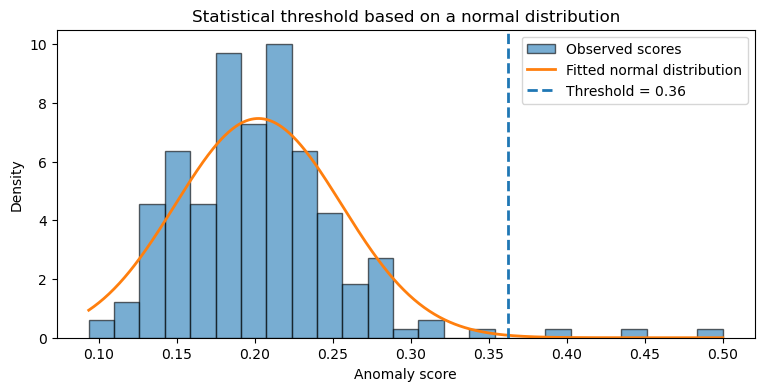

In [29]:
from scipy.stats import norm

x = np.linspace(scores.min(), scores.max(), 500)
pdf = norm.pdf(x, mu, sigma)

plt.figure(figsize=(9, 4))

plt.hist(
    scores,
    bins=25,
    density=True,
    alpha=0.6,
    edgecolor="black",
    label="Observed scores"
)

plt.plot(
    x,
    pdf,
    linewidth=2,
    label="Fitted normal distribution"
)

plt.axvline(
    threshold,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {threshold:.2f}"
)

plt.xlabel("Anomaly score")
plt.ylabel("Density")
plt.title("Statistical threshold based on a normal distribution")
plt.legend()

plt.show()

Here we are modeling the score distribution and placing the threshold in its upper tail, rather than simply choosing a percentile of the observed score.

**Note:** Because the example contains the high-score observations when estimating mu and sigma, they influence the fitted distribution and therefore the threshold. That's actually useful for illustrating why distributional assumptions and contamination matter.

<a id="6.3"></a>
<h3 align="left">
  <span style="color: #9C2007;">6.3. Robust statistical thresholds</span>
</h3>


Statistical thresholds based on the mean and standard deviation can be strongly affected by extreme scores.

This is problematic in anomaly detection because extreme scores may be exactly the observations we want to identify.

A robust alternative is to use statistics that are less sensitive to outliers, such as the **median** and **median absolute deviation (MAD)**.

Given scores \(s_1,\ldots,s_n\):

$$
m = \operatorname{median}(s)
$$

$$
MAD = \operatorname{median}(|s_i-m|)
$$

A simple robust threshold can then be defined as:

$$
\tau = m + k \cdot MAD
$$

where \(k\) controls how far into the upper tail the threshold is placed.

**What is this doing?**

Instead of estimating the center and spread using the mean and standard deviation, we estimate them using statistics that are much less affected by a small number of extreme observations.

The goal is therefore to identify scores that are unusually high **relative to the typical behavior of the calibration data**, without allowing a few extreme scores to substantially shift the threshold.

**Assumptions**

The main assumption is that **most of the calibration data represents normal behavior**.

The method does not require the scores to follow a particular parametric distribution, but it does require enough non-anomalous observations for the median and MAD to represent the typical score distribution.

**When is it useful?**

Robust statistical thresholding is particularly useful when:

* calibration data may contain some anomalies;
* extreme scores are present;
* mean and standard deviation are noticeably affected by those extremes;
* a parametric distribution such as a Gaussian is not appropriate.

**Limitations**

The method still requires choosing \(k\), and its effectiveness depends on the assumption that contamination is limited.

It can also be inadequate when the normal score distribution is strongly multimodal, highly non-stationary, or when anomalies make up a substantial fraction of the calibration data.

The choice of \(k\) is therefore another operating-point decision rather than a universally correct constant.


In [36]:
scores = np.array([
    0.10, 0.11, 0.12, 0.13, 0.14,
    0.15, 0.16, 0.17, 0.18, 0.19,
    0.80
])

# Ordinary statistics
mean = scores.mean()
std = scores.std()
statistical_threshold = mean + 3 * std

# Robust statistics
median = np.median(scores)
mad = np.median(np.abs(scores - median))
robust_threshold = median + 6 * mad

results = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Standard deviation",
        "Median",
        "MAD",
        "Statistical threshold",
        "Robust threshold",
    ],
    "Value": [
        mean,
        std,
        median,
        mad,
        statistical_threshold,
        robust_threshold,
    ],
})

results

,Statistic,Value
0,Mean,0.204545
1,Standard deviation,0.190280
2,Median,0.150000
3,MAD,0.030000
4,Statistical threshold,0.775387
5,Robust threshold,0.330000


Here the 0.80 score has a strong influence on the mean and standard deviation, while its influence on the median and MAD is much smaller.

<a id="5"></a>
<h2 align="center">
  <span style="color: #440E03;">7. Supervised threshold selection</span>
</h2>

In the supervised setting, anomaly labels are available for the data used to select the threshold.

This changes the problem fundamentally: instead of inferring where the upper tail of the score distribution lies, we can evaluate how different thresholds classify known normal and anomalous observations.

The threshold can therefore be selected according to an explicit **decision objective**.

The main approaches considered here are:

1. **Metric-based threshold selection** — choose the threshold that optimizes a metric such as F1.
2. **Constraint-based threshold selection** — choose a threshold that satisfies an operational requirement, such as a minimum recall or maximum false-positive rate.
3. **Cost-sensitive threshold selection** — choose a threshold based on the relative cost of false positives and false negatives.

The labeled data used for this process should be a **validation/calibration set**, not the final test set.

**Key difference from the unsupervised setting**

Without labels:

$$
\text{scores} \rightarrow \text{threshold}
$$

With labels:

$$
\text{scores + labels} \rightarrow \text{candidate thresholds} \rightarrow \text{decision objective} \rightarrow \text{threshold}
$$

This allows the threshold to be chosen according to the actual detection objective rather than only the statistical properties of the scores.


<a id="5.1"></a>
<h3 align="left">
  <span style="color: #9C2007;">7.1. Metric-based threshold selection</span>
</h3>

A straightforward supervised approach is to evaluate a range of candidate thresholds and select the one that optimizes a chosen classification metric.

For each candidate threshold tau:

$$
\hat{y}_i = 
\begin{cases} 
1 & \text{if } s_i > \tau \\ 
0 & \text{if } s_i \le \tau 
\end{cases}
$$

We then calculate a metric such as precision, recall, or F1.

For example, maximizing F1 selects the threshold that provides the best balance between precision and recall on the validation data.

**What is this doing?**

The threshold is treated as a decision parameter. Rather than assuming where the threshold should be, we use the labeled validation data to determine which threshold produces the desired metric value.

**Assumptions**

The validation labels should be reasonably representative of the conditions in which the detector will operate.

The chosen metric must also reflect the actual objective. Optimizing F1, for example, implicitly gives equal importance to precision and recall through the F1 formulation.

**When is it useful?**

Metric-based selection is useful when:

- reliable validation labels are available;
- a standard classification metric represents the desired operating point;
- there is no separate operational constraint that must be satisfied.

**Limitation

The threshold optimized for one metric is not necessarily appropriate for another objective.

For example, the threshold maximizing F1 is not necessarily the threshold providing the highest recall or the lowest false-positive rate.

In [43]:
# threshold maximizing F1


scores = np.array([
    0.10, 0.12, 0.15, 0.18, 0.20,
    0.22, 0.25, 0.40, 0.55, 0.70
])

labels = np.array([
    0, 0, 0, 0, 0,
    0, 0, 1, 1, 1
])

thresholds = np.linspace(scores.min(), scores.max(), 100)

f1_scores = []

for threshold in thresholds:
    predictions = (scores > threshold).astype(int)
    f1_scores.append(f1_score(labels, predictions))

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"best_threshold: {best_threshold}, best_f1: {best_f1}")

best_threshold: 0.2515151515151515, best_f1: 1.0


**Threshold and Classification Metrics**

The choice of threshold directly determines the trade-off between precision and recall.

As the threshold increases, fewer observations are classified as anomalies. This generally reduces recall while increasing precision. The F1 score reflects the resulting balance between the two.

The following plot shows how these metrics change as the threshold varies.

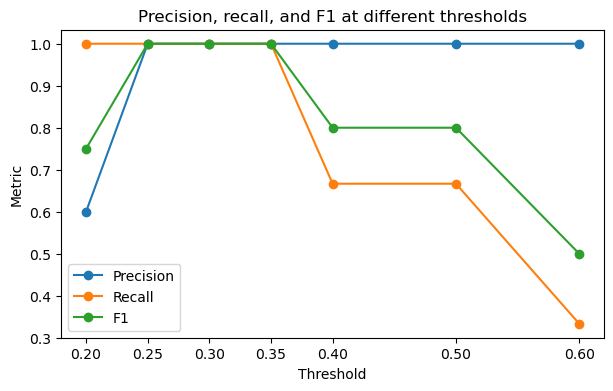

In [54]:
selected_thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60]

results = []

for threshold in selected_thresholds:
    predictions = (scores > threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(labels, predictions, zero_division=0),
        "Recall": recall_score(labels, predictions, zero_division=0),
        "F1": f1_score(labels, predictions, zero_division=0),
    })

results_df = pd.DataFrame(results)

results_df

plt.figure(figsize=(7, 4))

plt.plot(
    results_df["Threshold"],
    results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    results_df["Threshold"],
    results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    results_df["Threshold"],
    results_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.title("Precision, recall, and F1 at different thresholds")
plt.xticks(selected_thresholds)
plt.legend()

plt.show()

<a id="7.2"></a>
<h3 align="left">
  <span style="color: #9C2007;">7.2. Constraint-based threshold selection</span>
</h3>


In many anomaly-detection applications, there is a specific requirement that the threshold must satisfy.

Instead of optimizing a metric, we can formulate threshold selection as a **constraint**.

For example:

* recall must be at least 90%;
* false-positive rate must remain below 1%;
* the system can generate at most a certain number of alerts.

We evaluate candidate thresholds and retain those that satisfy the constraint.

For example, if the requirement is minimum recall:

$$
Recall(\tau) \geq R_{\min}
$$

the selected threshold can be the **highest threshold that satisfies the required recall**.

**What is this doing?**

The threshold is chosen to satisfy an explicit operating requirement rather than to maximize a general-purpose metric.

This is useful when one type of error has a practical limit that must not be exceeded.

**Assumptions**

The constraint should reflect a real operational requirement, and the validation data should be representative of the expected operating conditions.

**When is it useful?**

Constraint-based selection is particularly useful when:

* missing an anomaly has a strict cost or requirement;
* the number of false alerts must be controlled;
* the system has a known alerting capacity;
* a minimum or maximum performance level must be guaranteed on validation data.

**Limitation**

A constraint may leave multiple valid thresholds.

An additional rule is then needed to choose among them. For example, after requiring recall ≥ 90%, we might select the highest threshold satisfying that requirement to avoid unnecessary false positives.


In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score

selected_thresholds = [0.20, 0.30, 0.40, 0.50, 0.60]
min_recall = 0.90

results = []

for threshold in selected_thresholds:
    predictions = (scores > threshold).astype(int)

    precision = precision_score(labels, predictions, zero_division=0)
    recall = recall_score(labels, predictions, zero_division=0)
    f1 = f1_score(labels, predictions, zero_division=0)

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Valid": recall >= min_recall,
    })

results_df = pd.DataFrame(results)

# Select the highest threshold satisfying the recall constraint
valid_thresholds = results_df.loc[
    results_df["Valid"],
    "Threshold"
]

selected_threshold = valid_thresholds.max()

results_df["Selected"] = (
    results_df["Threshold"] == selected_threshold
)

results_df

,Threshold,Precision,Recall,F1,Valid,Selected
0,0.2,0.6,1.000000,0.75,True,False
1,0.3,1.0,1.000000,1.00,True,True
2,0.4,1.0,0.666667,0.80,False,False
3,0.5,1.0,0.666667,0.80,False,False
4,0.6,1.0,0.333333,0.50,False,False


<a id="7.3"></a>
<h3 align="left">
  <span style="color: #9C2007;">7.3. Cost-sensitive threshold selection</span>
</h3>

Precision, recall, and F1 treat classification errors indirectly. In some applications, however, the consequences of false positives and false negatives are substantially different.

A cost-sensitive approach makes these differences explicit.

For a given threshold, we can define a total cost such as:

$$
[
Cost(\tau) =
C_{FP} \cdot FP(\tau)
+
C_{FN} \cdot FN(\tau)
]
$$

where:

- (FP) is the number of false positives;
- (FN) is the number of false negatives;
- (C_{FP}) is the cost assigned to a false positive;
- (C_{FN}) is the cost assigned to a false negative.

The threshold is then selected to minimize the total cost on the validation data.

**What is this doing?**

Instead of asking:

Which threshold gives the highest F1?

or:

Which threshold satisfies a minimum recall?

we ask:

    Which threshold produces the lowest expected cost given the relative consequences of the two types of errors?

For example, if missing an anomaly is considered much more costly than generating a false alert, we can assign:

$$
[
C_{FN} > C_{FP}
]
$$

This will generally favor thresholds that reduce false negatives, even if they produce more false positives.

**Assumptions**

The relative costs must be meaningful enough to encode into the decision rule.

The validation data should also be representative of the expected frequency of normal and anomalous observations. Otherwise, the number of false positives and false negatives observed during calibration may not reflect the operational situation.

**When is it useful?**

Cost-sensitive selection is useful when:

- false positives and false negatives have clearly different consequences;
- operational or business costs can be estimated;
- there is no single metric that adequately represents the desired trade-off.

**Limitation**

The result depends directly on the chosen cost values.

If the costs are poorly estimated, the resulting threshold may not represent the actual operational objective. Cost-sensitive thresholding therefore makes the decision assumptions explicit rather than eliminating them.

In [65]:
selected_thresholds = [0.20, 0.30, 0.40, 0.50, 0.60]

cost_fp = 1
cost_fn = 5

results = []

for threshold in selected_thresholds:
    predictions = (scores > threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions
    ).ravel()

    total_cost = (
        cost_fp * fp +
        cost_fn * fn
    )

    results.append({
        "Threshold": threshold,
        "FP": fp,
        "FN": fn,
        "Cost": total_cost,
    })

cost_results = pd.DataFrame(results)

selected_threshold = cost_results.loc[
    cost_results["Cost"].idxmin(),
    "Threshold"
]

cost_results["Selected"] = (
    cost_results["Threshold"] == selected_threshold
)

cost_results

,Threshold,FP,FN,Cost,Selected
0,0.2,2,0,2,False
1,0.3,0,0,0,True
2,0.4,0,1,5,False
3,0.5,0,1,5,False
4,0.6,0,2,10,False


<a id="8"></a>
<h2 align="center">
  <span style="color: #440E03;">8. Threshold stability and sensitivity</span>
</h2>


Selecting a threshold is not enough. We also need to understand how sensitive that threshold is to changes in the data and the threshold-selection method.

A threshold may appear appropriate on one calibration dataset but change substantially when:

- a different calibration sample is used;
- the calibration data contains different levels of contamination;
- a parameter such as the selected quantile or statistical multiplier is changed.

This matters because an unstable threshold can lead to inconsistent behavior when the detector is deployed.

We will examine three related aspects:

- Sensitivity to calibration data
- Sensitivity to method parameters
- Overall threshold stability

The goal is not to find a perfectly stable threshold, but to understand how much the selected operating point depends on the assumptions and data used during calibration.

<a id="8.1"></a>
<h3 align="left">
  <span style="color: #9C2007;">8.1. Sensitivity to calibration data</span>
</h3>

The threshold is estimated from calibration data, so changing that data can change the selected threshold.

This is particularly relevant for unsupervised methods because the threshold is determined from the score distribution itself.

For example, a quantile threshold depends directly on the observations used to estimate that quantile. A statistical threshold depends on the estimated distribution parameters.

A useful analysis is therefore to repeatedly select the threshold using different samples of the calibration data and examine the resulting values.

If the thresholds vary substantially, the calibration procedure is sensitive to the particular sample used.

The following example performs a non-parametric bootstrap resampling procedure to evaluate the stability and uncertainty of a 90th-percentile cutoff score. By repeatedly sampling the original scores dataset with replacement 100 times, calculating the $0.90$ quantile for each pseudo-sample, and summarizing the results via descriptive statistics and a visual histogram, it measures how sensitive the chosen threshold is to random variations in calibration data.

Mean threshold: 0.513
Std threshold:  0.003
Min threshold:  0.504
Max threshold:  0.521


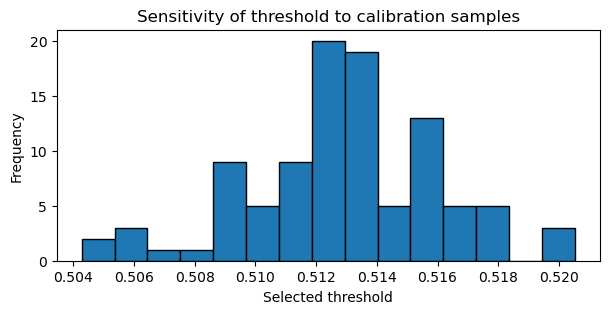

In [71]:
rng = np.random.default_rng(42)

thresholds = []

for _ in range(100):
    sample = rng.choice(scores, size=len(scores), replace=True)
    threshold = np.quantile(sample, 0.90)
    thresholds.append(threshold)

thresholds = np.array(thresholds)

print(f"Mean threshold: {thresholds.mean():.3f}")
print(f"Std threshold:  {thresholds.std():.3f}")
print(f"Min threshold:  {thresholds.min():.3f}")
print(f"Max threshold:  {thresholds.max():.3f}")

# visualize the variation
# plots a histogram displaying the empirical distribution of the estimated threshold
plt.figure(figsize=(7, 3))

plt.hist(thresholds, bins=15, edgecolor="black")

plt.xlabel("Selected threshold")
plt.ylabel("Frequency")
plt.title("Sensitivity of threshold to calibration samples")

plt.show()

<a id="8.2"></a>
<h3 align="left">
  <span style="color: #9C2007;">8.2. Sensitivity to method parameters</span>
</h3>

Threshold-selection methods often contain parameters that directly affect the resulting threshold.

Examples include:

- the quantile (q) in quantile-based thresholding;
- the multiplier (k) in statistical or robust thresholds;
- the minimum recall in constraint-based selection;
- the relative costs in cost-sensitive selection.

Changing these parameters changes the operating point.

It is therefore useful to examine how strongly the selected threshold depends on them.

**Example:** Quantile Thresholding

For a fixed calibration dataset, we can evaluate several quantiles and observe the resulting thresholds.

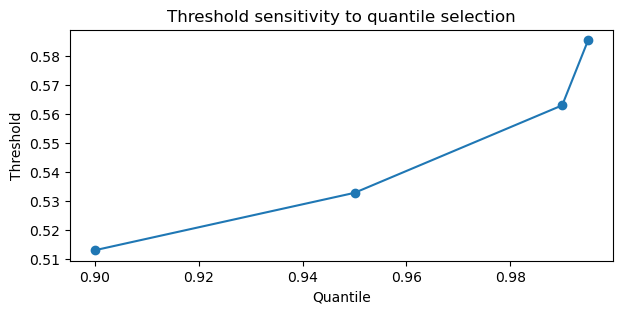

In [73]:
quantiles = [0.90, 0.95, 0.99, 0.995] 

results = [] 
for q in quantiles: 
    threshold = np.quantile(scores, q) 
    results.append({ "Quantile": q, "Threshold": threshold, }) 
    

results_df = pd.DataFrame(results) 

plt.figure(figsize=(7, 3)) 
plt.plot( results_df["Quantile"], results_df["Threshold"], marker="o" ) 
plt.xlabel("Quantile") 
plt.ylabel("Threshold") 
plt.title("Threshold sensitivity to quantile selection") 

plt.show()

The important point is that the quantile is not merely an implementation detail. It represents a choice about the desired operating point.


A threshold should not be considered meaningful without considering the assumptions and parameters that produced it. If a small change in a parameter causes a large change in the threshold, the resulting operating point may be highly sensitive to that choice.

<a id="8.3"></a>
<h3 align="left">
  <span style="color: #9C2007;">8.3. Threshold stability</span>
</h3>

The previous sections examined two sources of threshold variation:

- changes in the calibration data;
- changes in method parameters.

Together, these can be used to assess threshold stability.

A stable threshold should not change dramatically under small, reasonable changes in the calibration procedure.

This does not mean that the threshold must remain exactly constant. Some variation is expected, particularly with small calibration datasets or rare anomalies.

    A threshold is operationally stable when reasonable changes in calibration data, assumptions, or parameters do not cause disproportionate changes in the system's future anomaly decisions or alerting behavior.


The goal is to determine whether the selected operating point is reasonably robust to plausible changes in the calibration process.

**Practical analysis**

A useful approach is to repeat the threshold-selection procedure under several reasonable conditions and examine the resulting thresholds.

Mean threshold: 0.534
Std threshold:  0.003
Min threshold:  0.530
Max threshold:  0.541


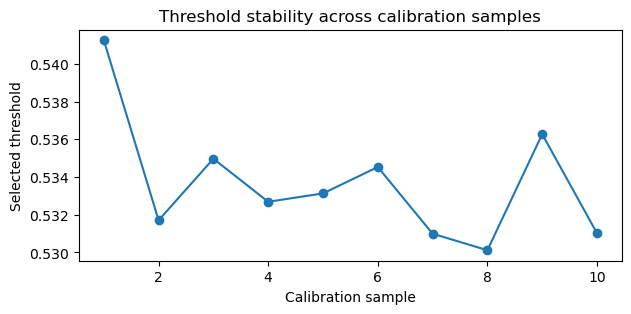

In [76]:
thresholds = []

for seed in range(10):
    rng = np.random.default_rng(seed)

    sample = rng.choice(
        scores,
        size=len(scores),
        replace=True
    )

    threshold = np.quantile(sample, 0.95)
    thresholds.append(threshold)

thresholds = np.array(thresholds)

print(f"Mean threshold: {thresholds.mean():.3f}")
print(f"Std threshold:  {thresholds.std():.3f}")
print(f"Min threshold:  {thresholds.min():.3f}")
print(f"Max threshold:  {thresholds.max():.3f}")


# simple visualization
plt.figure(figsize=(7, 3))

plt.plot(
    range(1, len(thresholds) + 1),
    thresholds,
    marker="o"
)

plt.xlabel("Calibration sample")
plt.ylabel("Selected threshold")
plt.title("Threshold stability across calibration samples")

plt.show()

The same idea can be extended beyond a single method. For example, we could compare thresholds produced by quantile, statistical, and robust approaches under the same calibration conditions.

**Key idea**

Threshold stability is not a separate threshold-selection method. It is a diagnostic step that helps determine whether the selected threshold is sensitive to the data and assumptions used to obtain it.

<a id="9"></a>
<h2 align="center">
  <span style="color: #440E03;">9. Thresholding for temporal and windowed data</span>
</h2>


Threshold selection becomes more involved when anomaly scores are produced from temporal or windowed data.

In this setting, consecutive observations may be dependent, the score distribution can change over time, and overlapping windows can cause a single event to influence multiple scores.

The threshold should therefore be calibrated using the same temporal structure and scoring procedure that will be used during deployment.

We will focus on three aspects:

Temporal calibration — how the choice of calibration period affects the threshold.
Window-level scores and labels — how the unit used for scoring affects threshold selection.
Overlapping windows — how overlap affects score dependence and anomaly labels.

<a id="9.1"></a>
<h3 align="left">
  <span style="color: #9C2007;">9.1. Temporal calibration</span>
</h3>

For temporal data, the calibration period should represent the operating conditions in which the threshold will be used.

A random sample from the entire time series can mix observations from different points in time and potentially expose the calibration process to future operating conditions that would not have been available at deployment.

A typical setup is therefore:

$$
[
\text{Training period}
\rightarrow
\text{Calibration/validation period}
\rightarrow
\text{Future test period}
]
$$

The detector is fitted using the training period, the threshold is selected using the calibration period, and the future test period is kept for the final evaluation.

**Why does the calibration period matter?**

Suppose the score distribution changes over time because the underlying system changes.

A threshold calibrated during one operating regime may no longer be appropriate in another regime.

For example, if normal scores were typically around:

$$
[
s \approx 0.2
]
$$

during calibration but later increase to:

$$
[
s \approx 0.4
]
$$

even without anomalies, a threshold calibrated on the earlier period may generate a large number of false alerts.

This is a form of distribution shift in the anomaly scores.

**Temporal ordering**

When observations have temporal dependence, the calibration procedure should respect the information that would actually be available at deployment.

For example, if the goal is to detect future anomalies:

```
Past data              Future data
───────────────┬──────────────────────────────
   Training    │ Calibration │     Test
               │             │
      fit      │  threshold  │ final evaluation
               │  selection  │
```  

Using future observations to determine the threshold can introduce temporal leakage.

**Non-stationary systems**

If the score distribution changes over time, a single global threshold may eventually become outdated.

Possible responses include:

- recalibrating the threshold periodically;
- using a rolling calibration window;
- defining thresholds separately for known operating regimes.

However, recalibration is itself a modeling decision. The recalibration procedure must use only information that would have been available at that point in time.

**Key idea**

For temporal anomaly detection, threshold calibration is not only a question of which method to use. It is also a question of which time period is used to estimate the threshold.

The calibration data should represent the operating regime of interest while respecting the temporal information available at deployment

In [77]:
# code example...
# Chronological calibration calibration_scores = scores[:100]

<a id="9.2"></a>
<h3 align="left">
  <span style="color: #9C2007;">9.2. Window-Level Scores and Labels</span>
</h3>


When an anomaly detector operates on windows, the threshold is applied to a window-level score, rather than directly to individual observations.

For a window

$$
X_t = [x_{t-w+1}, x_{t-w+2}, \ldots, x_t]
$$

the detector produces a score:

$$
s_t = f(X_t).
$$

The threshold then determines whether that window is considered anomalous:

$$
\hat{y}_t =
\begin{cases}
1 & \text{if } s_t > \tau \
0 & \text{otherwise.}
\end{cases}
$$

**The calibration unit must match the deployment unit**

If the deployed detector produces one score per window, the threshold should be calibrated using window-level scores.

For example:

``` 
Raw observations
      ↓
Windowing
      ↓
Window scores
      ↓
Threshold
      ↓
Window-level predictions
``` 

The threshold should therefore not be selected from raw point-level values if the deployed system will make decisions from window-level scores.

**Window-level labels**

When point-level anomaly labels are available, they must also be mapped to the same window-level representation.

A common rule is:

$$
y_t^{window} =
\begin{cases}
1 & \text{if any observation in the window is anomalous} \
0 & \text{otherwise.}
\end{cases}
$$

For example:

Point labels:
0  0  1  0  0  0

Window size = 3

Windows:
```
[0 0 1] → 1
[0 1 0] → 1
[1 0 0] → 1
[0 0 0] → 0
``` 

This means that a single anomalous observation can cause several overlapping windows to receive an anomalous label.

**Why this matters for threshold selection**

The threshold itself is still a comparison between a score and a value:

$$
s_t > \tau.
$$

However, the meaning of metrics such as precision, recall, and F1 depends on the unit of evaluation.

A high window-level recall, for example, means that anomalous windows are being detected well. It does not necessarily mean that individual anomalous points or complete anomaly events are being detected equally well.

Therefore, when working with windowed data, it is important to state explicitly:

- what constitutes one score;
- what constitutes one label;
- what unit the threshold operates on;
- and what unit the evaluation metrics describe.


**Key idea**

The threshold-selection procedure should be performed at the same level at which the detector makes decisions.

If the model produces window-level scores, threshold calibration and the corresponding validation metrics should normally be defined at the window level.

In [78]:
#.. maybe a code example..

<a id="9.3"></a>
<h3 align="left">
  <span style="color: #9C2007;">9.3. Overlapping windows</span>
</h3>

When the stride is smaller than the window size, consecutive windows overlap.

For example, with a window size of (w=5) and a stride of (1):

```
Window 1: [x₁ x₂ x₃ x₄ x₅]
Window 2:    [x₂ x₃ x₄ x₅ x₆]
Window 3:       [x₃ x₄ x₅ x₆ x₇]
``` 

The resulting window scores are therefore NOT independent observations. Consecutive scores share most of their input data.

**Effect on anomaly labels**

Overlapping windows can also cause a single point-level anomaly to appear in multiple windows.

For example, suppose (x5) is anomalous, then:

```
Window 1: [x₁ x₂ x₃ x₄ x₅] → anomalous
Window 2: [x₂ x₃ x₄ x₅ x₆] → anomalous
Window 3: [x₃ x₄ x₅ x₆ x₇] → anomalous
Window 4: [x₄ x₅ x₆ x₇ x₈] → anomalous
Window 5: [x₅ x₆ x₇ x₈ x₉] → anomalous
``` 

if the window-labeling rule is:

$$
y_t^{window}=1
\quad\text{if any point in the window is anomalous.}
$$

Thus, one point-level event can generate several anomalous window labels.

**Why this matters**

This has two important consequences.

1. The effective anomaly rate at the window level can be much higher than the anomaly rate at the point level.

2. Evaluation metrics computed on overlapping windows should not automatically be interpreted as point-level or event-level performance.

For example, detecting five anomalous windows does not necessarily mean that five independent anomalies were detected. They may all correspond to the same underlying event.

**Effect on threshold selection**

The threshold is still calibrated using the distribution of window-level scores, but the interpretation of that distribution depends on the windowing configuration.

Changing the:

- window size;
- stride;
- window-labeling rule;

can change the score distribution, the number of anomalous windows, and therefore the resulting threshold and validation metrics.

Consequently, the windowing configuration is part of the threshold-calibration setup.

It should be fixed before comparing threshold-selection strategies.

**Key idea**

Overlapping windows do not invalidate thresholding, but they change the statistical structure and interpretation of the resulting scores and labels.

When reporting threshold-selection results, it is therefore important to specify the window size, stride, scoring unit, and labeling rule.

In [79]:
#..cpode example....?

<a id="10"></a>
<h2 align="center">
  <span style="color: #440E03;">10. Practical Decision Guide</span>
</h2>

The appropriate threshold-selection strategy depends primarily on the information available and the operational objective.

A useful way to approach the problem is to ask the following questions.

1. Are reliable anomaly labels available?

No labels

The threshold must be inferred from the score distribution.

Possible approaches include:

Quantile-based thresholding when controlling the fraction of scores flagged is the main objective.
Statistical thresholding when a suitable distributional model can reasonably describe the scores.
Robust statistical thresholding when the calibration data may contain some contamination or extreme values.

Labels available

The threshold can be selected directly using the known outcomes.

Possible approaches include:

Metric-based selection when a classification metric represents the desired objective.
Constraint-based selection when there is a specific requirement such as minimum recall or maximum false-positive rate.
Cost-sensitive selection when false positives and false negatives have different consequences that can be quantified.
2. What is the operating objective?

The threshold should reflect what the system is expected to achieve.

For example:

Situation	Relevant approach
No labels, control alert rate	Quantile
No labels, score distribution is reasonably modeled	Statistical
No labels, some contamination is expected	Robust statistical
Labels, optimize a general metric	Metric-based
Labels, satisfy a required recall/FPR	Constraint-based
Labels, error costs can be estimated	Cost-sensitive

These are not mutually exclusive rules. The same dataset may support several approaches, but they represent different assumptions and decision objectives.

3. Is the data temporal or windowed?

If the detector operates on temporal or windowed data, threshold selection should also consider:

whether the calibration period represents the deployment regime;
whether future information could leak into calibration;
whether the threshold is applied to point-level or window-level scores;
whether overlapping windows create correlated scores and repeated labels.

The thresholding method should be evaluated using the same scoring and windowing procedure that will be used during deployment.

4. Is the threshold stable?

After selecting a threshold, examine whether reasonable changes to:

the calibration sample;
method parameters;
or other calibration assumptions

produce disproportionate changes in the resulting operating behavior.

Stability is a diagnostic, not a separate threshold-selection method.

Final principle

Threshold selection is a decision problem, not simply a mathematical operation on anomaly scores.

A defensible threshold should therefore answer four questions:

What information was available?
What assumptions were made?
What objective or constraint determined the operating point?
How robust is the resulting decision to reasonable changes in the calibration process?

Making these choices explicit is more important than selecting a particular thresholding method by default.